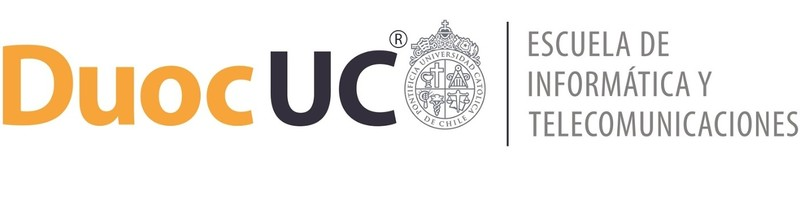

# Informe Técnico - Evaluacion 1 Mineria de Datos
# nombres: Patricio Gonzalez Rodrigo Riveros
# Seccion: 001D

# Paso 1 Importar librerias

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Paso 2 Cargar el Dataset

In [3]:
# Configuración para ver todas las columnas
pd.set_option('display.max_columns', None)
# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)
#pd.set_option('display.max_colwidth', None)

In [4]:
#cargar los datos
df = pd.read_csv("reels_attention_span_dataset_12000.csv", low_memory= False)
df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels


In [5]:
df.tail()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
11995,11996,27,4.14,6.29,7.71,4.96,3.00,97.38,High,TikTok
11996,11997,42,4.07,3.27,4.20,1.02,3.30,40.79,High,Instagram Reels
11997,11998,25,0.82,3.19,6.16,7.59,1.30,41.71,Low,Instagram Reels
11998,11999,39,1.70,3.65,7.15,8.90,1.92,71.05,High,TikTok
11999,12000,33,5.79,10.91,4.35,5.36,3.65,91.36,High,TikTok


# Paso 3 Revisar los tipos de datos

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   reels_watch_time_hours   12000 non-null  float64
 3   daily_screen_time_hours  12000 non-null  float64
 4   sleep_hours              12000 non-null  float64
 5   attention_span_score     12000 non-null  float64
 6   focus_level              12000 non-null  float64
 7   task_completion_rate     12000 non-null  float64
 8   stress_level             12000 non-null  object 
 9   platform                 12000 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 937.6+ KB


In [7]:
df.shape

(12000, 10)

# Buscamos algun tipo de nulo

In [8]:
df.isnull().sum()

,0
user_id,0
age,0
reels_watch_time_hours,0
daily_screen_time_hours,0
sleep_hours,0
attention_span_score,0
focus_level,0
task_completion_rate,0
stress_level,0
platform,0


# al no tener nulos omitimos la limpieza de los nulos

# Explicacion de el dataset y su contenido:
El dataset reels_attention_span_dataset_12000.csv es un conjunto de datos diseñado para estudiar el impacto del consumo de videos cortos (Reels, TikTok, Shorts) en diversas métricas de bienestar y productividad de los usuarios

# Mapeo de Datos

# Clasificacion de Variables
Categorico Nominal: Categorías sin un orden o jerarquía específica.

Ejemplo: platform (Instagram Reels, TikTok, YouTube Shorts). No existe un orden lógico que diga que una plataforma es "mayor" o "menor" que otra.

Categorico Ordinal: Categorías que siguen un orden lógico o escala.

Ejemplo: stress_level. Posee una escala de intensidad clara: Low (Bajo) < Medium (Medio) < High (Alto).

Numerico Discreto: Valores que surgen de un conteo y no admiten decimales en este contexto.

Ejemplo: user_id (Identificador único de cada sujeto) y age (Edad expresada en años cumplidos).

Numerico Continuo: Valores que resultan de una medición y pueden tener decimales.

Ejemplos: * reels_watch_time_hours: Tiempo dedicado a reels (ej. 1.5 horas).

daily_screen_time_hours: Tiempo total de pantalla.

sleep_hours: Horas de sueño medidas con precisión.

attention_span_score: Puntaje obtenido en pruebas de atención.

focus_level: Nivel de enfoque medido.

task_completion_rate: Tasa de finalización (usualmente un porcentaje entre 0 y 100).


user_id: Numérico Discreto (Identificador único).

age: Numérico Discreto (Edad en años enteros).

reels_watch_time_hours: Numérico Continuo (Horas con decimales).

daily_screen_time_hours: Numérico Continuo (Horas con decimales).

sleep_hours: Numérico Continuo (Horas con decimales).

attention_span_score: Numérico Continuo (Puntaje de medición).

focus_level: Numérico Continuo (Nivel medido).

task_completion_rate: Numérico Continuo (Porcentaje o tasa).

stress_level: Categórico Ordinal (Tiene un orden lógico: Low < Medium < High).

platform: Categórico Nominal (Categorías sin un orden jerárquico: TikTok, Instagram, YouTube).

# Estadistica descriptiva a las variables numericas

In [12]:
df.describe().round()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level_num
count,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0
mean,6000.0,30.0,3.0,7.0,6.0,5.0,6.0,70.0,2.0
std,3464.0,9.0,2.0,3.0,1.0,3.0,3.0,17.0,1.0
min,1.0,15.0,0.0,2.0,4.0,1.0,1.0,40.0,1.0
25%,3001.0,22.0,2.0,5.0,5.0,3.0,3.0,55.0,1.0
50%,6000.0,30.0,3.0,7.0,6.0,5.0,6.0,70.0,2.0
75%,9000.0,37.0,5.0,9.0,8.0,8.0,8.0,85.0,3.0
max,12000.0,44.0,6.0,12.0,9.0,10.0,10.0,100.0,3.0


### Aplicación de OneHotEncoding
Utilizaremos `sklearn` para transformar la variable nominal `platform` en múltiples columnas binarias.

In [10]:
from sklearn.preprocessing import OneHotEncoder

# 1. Instanciar el codificador
ohe = OneHotEncoder(sparse_output=False)

# 2. Ajustar y transformar la columna 'platform'
platform_encoded = ohe.fit_transform(df[['platform']])

# 3. Crear un DataFrame con las nuevas columnas
platform_df = pd.DataFrame(
    platform_encoded,
    columns=ohe.get_feature_names_out(['platform']),
    index=df.index
)

# 4. Concatenar con el DataFrame original y ver resultado
df_final = pd.concat([df, platform_df], axis=1)

print("Nuevas columnas creadas por el Encoder:")
display(df_final.head())

Nuevas columnas creadas por el Encoder:


,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,stress_level_num,platform_Instagram Reels,platform_TikTok,platform_YouTube Shorts
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,2,0.0,1.0,0.0
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok,3,0.0,1.0,0.0
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok,1,0.0,1.0,0.0
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels,1,1.0,0.0,0.0
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels,1,1.0,0.0,0.0




### Mapeo de Stress Level: Low=1, Medium=2, High=3
Usamos un mapeo manual porque `stress_level` es una variable Ordinal (tiene orden)



In [9]:
# Mapeo de Stress Level: Low=1, Medium=2, High=3
# Usamos un mapeo manual porque 'stress_level' es una variable Ordinal (tiene orden)
mapeo_estres = {'Low': 1, 'Medium': 2, 'High': 3}
df['stress_level_num'] = df['stress_level'].map(mapeo_estres)

df.head()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform,stress_level_num
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok,2
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok,3
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok,1
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels,1
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels,1


con este mapeo lo que hacemos es que la columna stress level le cambiamos los valores para que asi pase de etiquetas cualitativas a valores numericos para que asi pueda sacar estadisticas y para futuro aplicarle modelos de correlacion

# Analisis de Correlacion

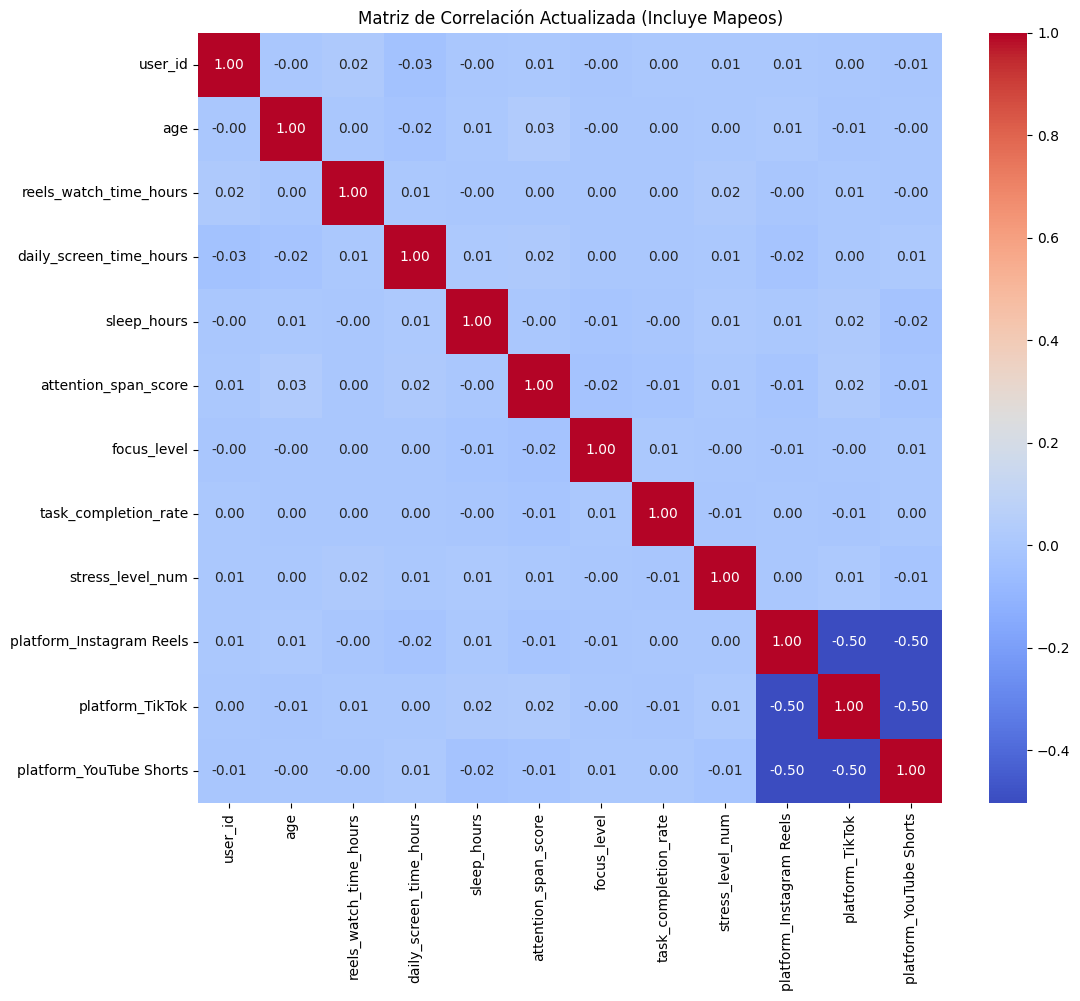

In [12]:
# Seleccionamos todas las columnas que ahora son numéricas (incluyendo los mapeos)
corr_df = df.select_dtypes(include=[np.number]).corr()

# Creamos el mapa de calor (Heatmap) actualizado
plt.figure(figsize=(12, 10))
sb.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación Actualizada (Incluye Mapeos)")
plt.show()

# Explicacion del Matriz de Calor
En este gráfico de correlación, buscamos valores cercanos a 1 o -1. Por ejemplo, si vemos una correlación negativa fuerte entre reels_watch_time_hours y attention_span_score, significa que a medida que aumenta el tiempo viendo videos, la capacidad de atención del usuario tiende a disminuir.

# Pregunta: ¿Influye el tiempo de visualización de Reels en la calidad del sueño?

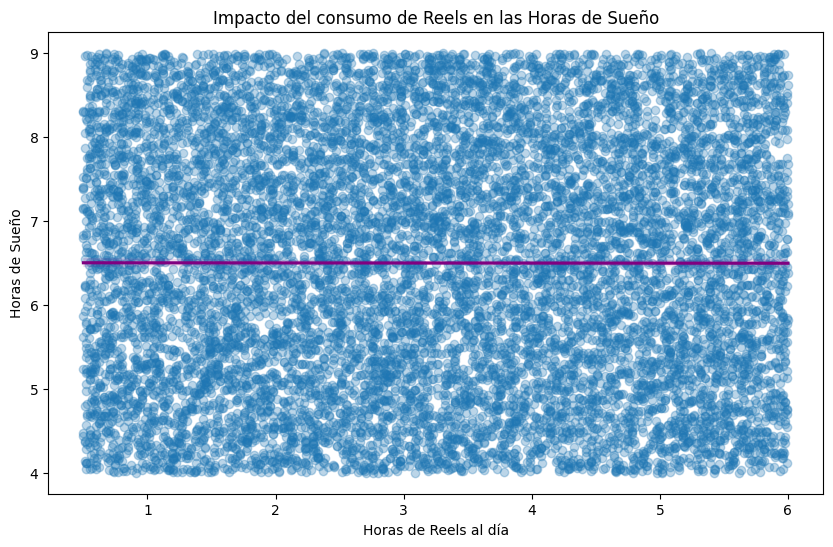

El coeficiente de correlación de Pearson es: -0.0011


In [19]:
# Graficamos la relación
plt.figure(figsize=(10, 6))
sb.regplot(data=df, x='reels_watch_time_hours', y='sleep_hours',
           scatter_kws={'alpha':0.3}, line_kws={'color':'purple'})
plt.title('Impacto del consumo de Reels en las Horas de Sueño')
plt.xlabel('Horas de Reels al día')
plt.ylabel('Horas de Sueño')
plt.show()

# Calculamos la correlación numérica para confirmar la falta de relación
correlacion = df['reels_watch_time_hours'].corr(df['sleep_hours'])
print(f"El coeficiente de correlación de Pearson es: {correlacion:.4f}")

# Explicacion
Al analizar la relación entre reels_watch_time_hours  y sleep_hours , observamos que la línea de regresión es horizontal. Esto indica una ausencia de correlación lineal significativa entre ambas variables en este conjunto de datos específico.
Esto sugiere que, para los usuarios de esta muestra, el tiempo que pasan viendo videos cortos no es el factor determinante que define cuántas horas duermen. Existen usuarios que ven muchos Reels y duermen 8 horas, así como usuarios que ven pocos y duermen solo 4.

# Pregunta 2: ¿Cuál es la plataforma donde los usuarios reportan mayor nivel de estrés?

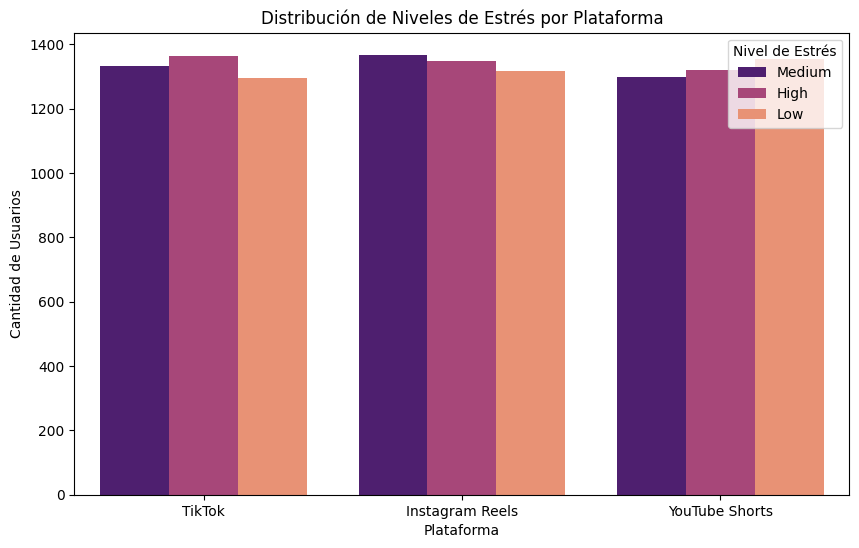

In [21]:
plt.figure(figsize=(10, 6))
sb.countplot(data=df, x='platform', hue='stress_level', palette='magma')
plt.title('Distribución de Niveles de Estrés por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Nivel de Estrés')
plt.show()

# Explicacion de el Grafico
Al comparar las plataformas, observamos que no hay una 'red social del estrés' dominante. La distribución de los niveles de estrés es bastante equilibrada entre Instagram, TikTok y YouTube. Esto sugiere que el impacto emocional en los usuarios es similar independientemente de la interfaz o el algoritmo específico de la plataforma de videos cortos.

Un punto relevante es que la mayoría de los usuarios se concentran en niveles de estrés Bajo y Medio. Esto podría interpretarse de dos formas: o el consumo de estos contenidos actúa como un distractor que mantiene el estrés controlado, o simplemente la muestra de 12,000 personas no presenta una patología de estrés agudo derivada directamente del uso de estas aplicaciones.

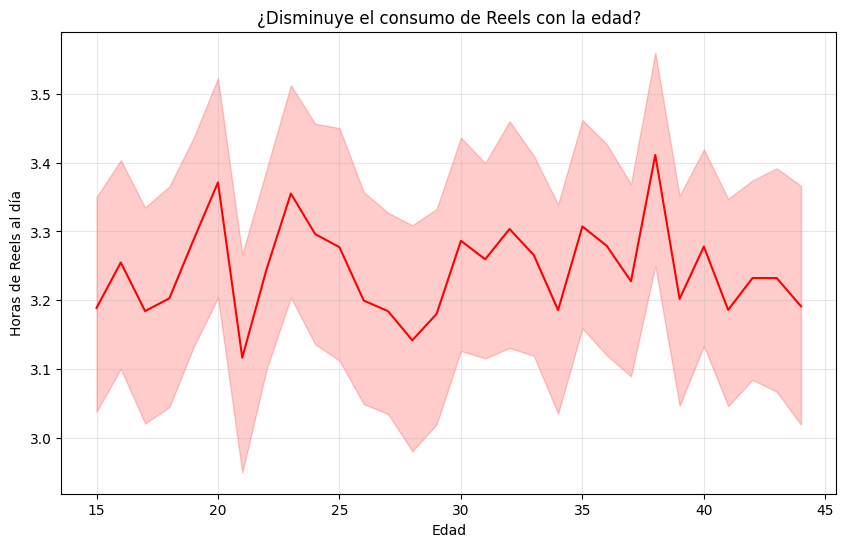

In [22]:
plt.figure(figsize=(10, 6))
sb.lineplot(data=df, x='age', y='reels_watch_time_hours', color='red')
plt.title('¿Disminuye el consumo de Reels con la edad?')
plt.xlabel('Edad')
plt.ylabel('Horas de Reels al día')
plt.grid(True, alpha=0.3)
plt.show()

### Análisis: Edad vs. Tiempo de Visualización de Reels

Al observar el gráfico de líneas, podemos identificar la tendencia del consumo de contenido corto en relación con la edad de los usuarios:

1. **Tendencia General**: El gráfico muestra fluctuaciones constantes sin una caída drástica o un aumento lineal evidente. Esto sugiere que el interés por los Reels no es exclusivo de los jóvenes, sino que se mantiene presente en diversos rangos etarios dentro de la muestra.
2. **Picos de Consumo**: Existen edades específicas donde el consumo se dispara, lo que podría estar relacionado con hábitos de uso en momentos de transición (estudiantes vs. trabajadores).
3. **Estabilidad**: La falta de una pendiente pronunciada indica que factores como el algoritmo de recomendación logran retener a los usuarios independientemente de su edad.

en otras palabras se podria dar a entender que tanto la edad con el consumo de reels no tiene una relacion podrias tener 20 años y ver una pequeña cantidad de reels al dia como tambien tener 60 años y ver muchos reels al dia